<a href="https://colab.research.google.com/github/NEFAxRAJ/Machine-Learning-Practices/blob/main/ANN_scratch_sigmoid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 ### **B7. Write Python code to implement the Backpropagation algorithm for an ANN with more than two hidden layers. Develop two such deep models with the following configurations.**
 **Model 1: uses sigmoid activations at the hidden nodes and softmax activation function at the output nodes.**

 **Model 2: uses ReLu activation function at the hidden nodes and softmax activation function at the output nodes.**

**Backpropagation** is a supervised learning algorithm used to train feedforward neural networks. It computes how much each weight contributes to the prediction error and updates the weights to minimize the loss function using gradient descent.

Core Idea (Intuition)

*   ANN makes a prediction using forward propagation
*   The prediction error is computed using a loss function

*   The error is propagated backwards through the network

*   Weights are updated in the direction that reduces the error

Forward Propagation Linear transformation (Layer 1)

$
Z^{(1)} = W^{(1)} X + b^{(1)}
$



Activation Functions-

$
\text{Sigmoid:}\quad \sigma(z) = \frac{1}{1 + e^{-z}}
$

$
\text{ReLU:}\quad \mathrm{ReLU}(z) = \max(0, z)
$

$
\text{Hidden layer activation:}\quad A^{(1)} = g\!\left(Z^{(1)}\right)
$


$
\text{Linear transformation (output layer):}\quad
Z^{(2)} = W^{(2)} A^{(1)} + b^{(2)}
$

$
\text{Softmax activation:}\quad
\mathrm{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
$

$
\text{Output probabilities:}\quad
A^{(2)} = \mathrm{softmax}\!\left(Z^{(2)}\right)
$


$
\text{Linear transformation (output layer):}\quad
Z^{(2)} = W^{(2)} A^{(1)} + b^{(2)}
$

$
\text{Softmax activation:}\quad
\mathrm{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
$

$
\text{Output probabilities:}\quad
A^{(2)} = \mathrm{softmax}\!\left(Z^{(2)}\right)
$


$
\text{Categorical Cross-Entropy Loss:}\quad
L = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K}
Y_{ik}\,\log\!\left(A^{(2)}_{ik}\right)
$


$
\text{Backpropagation:}\quad
\text{Gradients are computed using the chain rule.}
$

$
\text{Output layer error (softmax + cross-entropy):}\quad
\delta^{(2)} = A^{(2)} - Y
$

$
\text{Gradient w.r.t. } W^{(2)}:\quad
\frac{\partial L}{\partial W^{(2)}} =
\frac{1}{m}\,\delta^{(2)}\left(A^{(1)}\right)^{T}
$

$
\text{Gradient w.r.t. } b^{(2)}:\quad
\frac{\partial L}{\partial b^{(2)}} =
\frac{1}{m}\sum \delta^{(2)}
$


$
\text{Sigmoid derivative:}\quad
\sigma'(a) = a(1 - a)
$

$
\text{ReLU derivative:}\quad
\mathrm{ReLU}'(z) =
\begin{cases}
1, & z > 0 \\
0, & z \le 0
\end{cases}
$

$
\text{Hidden layer error:}\quad
\delta^{(1)} = \left(W^{(2)}\right)^{T}\delta^{(2)} \odot g'\!\left(Z^{(1)}\right)
$

$
\text{Gradient w.r.t. } W^{(1)}:\quad
\frac{\partial L}{\partial W^{(1)}} =
\frac{1}{m}\,\delta^{(1)} X^{T}
$

$
\text{Gradient w.r.t. } b^{(1)}:\quad
\frac{\partial L}{\partial b^{(1)}} =
\frac{1}{m}\sum \delta^{(1)}
$


$
\text{Gradient Descent Update Rule:}
$

$
W := W - \alpha \frac{\partial L}{\partial W},
\qquad
b := b - \alpha \frac{\partial L}{\partial b}
$

$
\text{This process is repeated for multiple iterations (epochs).}
$


$
\text{Prediction:}\quad
\hat{y} = \arg\max_{k} A^{(2)}_{k}
$

$
\text{Accuracy:}\quad
\text{Accuracy} =
\frac{\text{Number of correct predictions}}{\text{Total samples}}
$


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [5]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

data = pd.read_csv('/content/drive/MyDrive/fashion-mnist_train.csv')

In [6]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255.

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.
_,m_train = X_train.shape

**Model 1**

 Using sigmoid activations at the hidden nodes and softmax activation function at the output nodes.

In [7]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))


def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = sigmoid(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def sigmoid_deriv(A):
    return A * (1 - A)

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * sigmoid_deriv(A1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [8]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 100 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [9]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.1, 1000)

Iteration:  0
[3 3 3 ... 3 3 3] [5 4 4 ... 1 9 7]
0.10066101694915254
Iteration:  100
[8 2 2 ... 3 9 7] [5 4 4 ... 1 9 7]
0.5205254237288136
Iteration:  200
[8 2 4 ... 3 9 7] [5 4 4 ... 1 9 7]
0.6274576271186441
Iteration:  300
[8 2 4 ... 3 9 7] [5 4 4 ... 1 9 7]
0.6571525423728813
Iteration:  400
[8 2 4 ... 3 9 7] [5 4 4 ... 1 9 7]
0.6776949152542373
Iteration:  500
[8 2 4 ... 3 9 7] [5 4 4 ... 1 9 7]
0.6934067796610169
Iteration:  600
[8 2 4 ... 3 9 7] [5 4 4 ... 1 9 7]
0.7063728813559322
Iteration:  700
[8 2 4 ... 3 9 7] [5 4 4 ... 1 9 7]
0.7173898305084746
Iteration:  800
[5 2 4 ... 3 9 7] [5 4 4 ... 1 9 7]
0.7265254237288136
Iteration:  900
[5 2 4 ... 3 9 7] [5 4 4 ... 1 9 7]
0.7340508474576272


In [10]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [5]
Label:  5


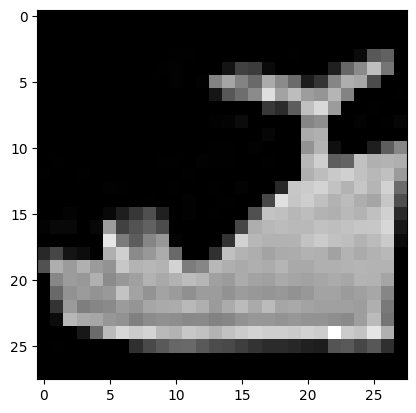

Prediction:  [2]
Label:  4


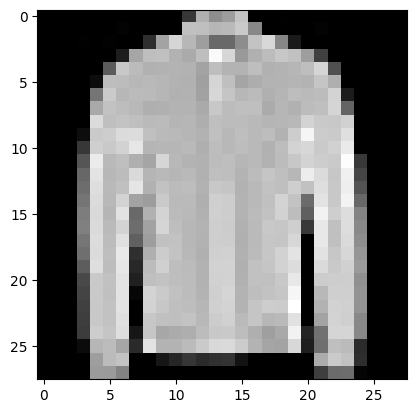

Prediction:  [4]
Label:  4


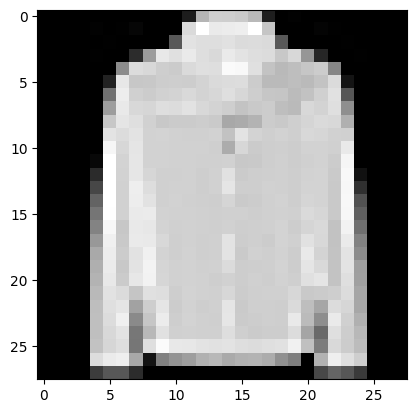

Prediction:  [3]
Label:  4


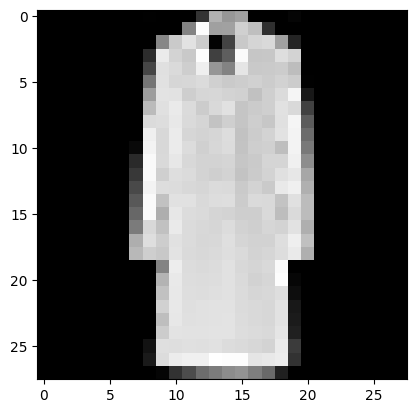

In [11]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)

**Model 2**

 Using ReLu activation function at the hidden nodes and softmax activation function at the output nodes.

In [12]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def ReLU_deriv(Z):
    return (Z > 0).astype(float)

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [13]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    if(iterations == 100):
      predictions = get_predictions(A2)
      print(iterations)
      print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [14]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.1, 100)

Iteration:  0
[0 6 6 ... 2 8 6] [5 4 4 ... 1 9 7]
0.11067796610169492
Iteration:  10
[9 4 4 ... 1 9 7] [5 4 4 ... 1 9 7]
0.38654237288135596
Iteration:  20
[9 4 4 ... 1 9 7] [5 4 4 ... 1 9 7]
0.4866779661016949
Iteration:  30
[9 4 4 ... 3 9 7] [5 4 4 ... 1 9 7]
0.5377118644067796
Iteration:  40
[9 4 4 ... 3 9 7] [5 4 4 ... 1 9 7]
0.5662203389830508
Iteration:  50
[9 4 4 ... 3 9 7] [5 4 4 ... 1 9 7]
0.5833050847457627
Iteration:  60
[9 4 4 ... 3 9 7] [5 4 4 ... 1 9 7]
0.5946610169491525
Iteration:  70
[9 4 4 ... 3 9 7] [5 4 4 ... 1 9 7]
0.6040338983050847
Iteration:  80
[9 4 4 ... 3 9 7] [5 4 4 ... 1 9 7]
0.6120677966101695
Iteration:  90
[9 2 2 ... 3 9 7] [5 4 4 ... 1 9 7]
0.5973050847457627
100
[5 4 4 ... 3 9 7] [5 4 4 ... 1 9 7]
0.6034406779661017


In [15]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [5]
Label:  5


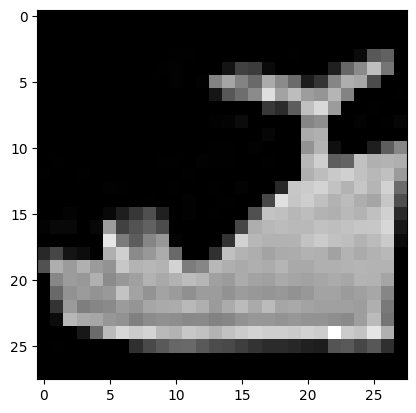

Prediction:  [2]
Label:  4


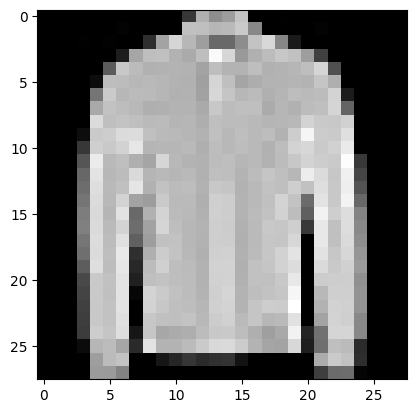

Prediction:  [2]
Label:  4


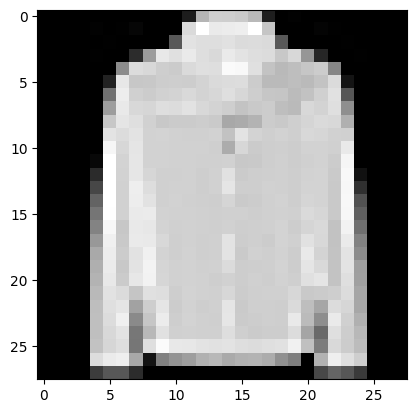

Prediction:  [3]
Label:  4


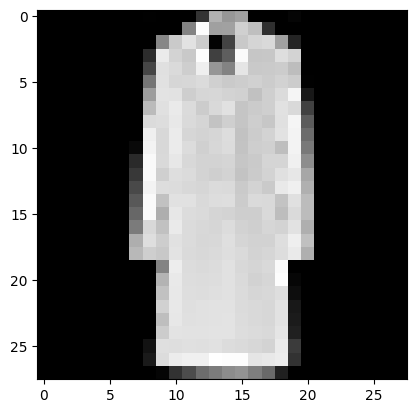

In [16]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)